In [7]:
from itertools import combinations
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

In [4]:
DATA_PATH = "../../data/shop_groceries.csv"
transactions = []

with open(DATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()

        if line == "":
            continue

        items = line.split(",")

        items = [item.strip() for item in items if item.strip() != ""]

        items = list(set(items))

        transactions.append(items)

num_transactions = len(transactions)

all_items = sorted(set(item for transaction in transactions for item in transaction))

num_items = len(all_items)

print("전체 거래 수:", num_transactions)
print("전체 고유 아이템 수:", num_items)

print("처음 5개 거래:")
for i, transaction in enumerate(transactions[:5], start=1):
    print(f"거래 {i}:", transaction)

전체 거래 수: 9835
전체 고유 아이템 수: 169
처음 5개 거래:
거래 1: ['ready soups', 'citrus fruit', 'semi-finished bread', 'margarine']
거래 2: ['tropical fruit', 'yogurt', 'coffee']
거래 3: ['whole milk']
거래 4: ['pip fruit', 'yogurt', 'meat spreads', 'cream cheese']
거래 5: ['whole milk', 'long life bakery product', 'condensed milk', 'other vegetables']


In [5]:
item_to_idx = {item: idx for idx, item in enumerate(all_items)}
idx_to_item = {idx: item for item, idx in item_to_idx.items()}

X = torch.zeros((num_transactions, num_items), dtype=torch.float32)

for row_idx, transaction in enumerate(transactions):
    for item in transaction:
        col_idx = item_to_idx[item]

        X[row_idx, col_idx] = 1.0

print("one-hot 행렬 크기:", X.shape)

print("처음 5개 거래 x 처음 10개 아이템 행렬:")
print(X[:5, :10])

print("처음 10개 아이템 이름:")
print(all_items[:10])

one-hot 행렬 크기: torch.Size([9835, 169])
처음 5개 거래 x 처음 10개 아이템 행렬:
tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])
처음 10개 아이템 이름:
['Instant food products', 'UHT-milk', 'abrasive cleaner', 'artif. sweetener', 'baby cosmetics', 'baby food', 'bags', 'baking powder', 'bathroom cleaner', 'beef']


In [8]:
item_support_tensor = X.mean(dim=0)
item_support = item_support_tensor.numpy()

item_freq_df = pd.DataFrame({
    "item": all_items,
    "support": item_support,
    "count": (item_support_tensor * num_transactions).to(torch.int64).numpy()
})

item_freq_df = item_freq_df.sort_values("support", ascending=False).reset_index(drop=True)

item_freq_df.head(10)

,item,support,count
0,whole milk,0.255516,2513
1,other vegetables,0.193493,1902
2,rolls/buns,0.183935,1809
3,soda,0.174377,1714
4,yogurt,0.139502,1372
5,bottled water,0.110524,1087
6,root vegetables,0.108998,1072
7,tropical fruit,0.104931,1032
8,shopping bags,0.098526,969
9,sausage,0.093950,923


In [10]:
def calculate_itemset_support(X, item_indices):
    item_indices = list(item_indices)
    selected = X[:, item_indices]
    both_purchased = selected.prod(dim=1)

    support = both_purchased.mean().item()
    return support

test_items = item_freq_df.head(2)["item"].tolist()

test_indices = [item_to_idx[item] for item in test_items]

test_support = calculate_itemset_support(X, test_indices)

print("테스트 아이템:", test_items)
print("동시 등장 지지도:", test_support)

테스트 아이템: ['whole milk', 'other vegetables']
동시 등장 지지도: 0.07483477145433426


# 실습문제 1. 최소 지지도 변경 실험 --------------------------------------------------
다음과 같이 최소 지지도를 변경하여 규칙 개수를 비교하시오.
```
0.005
0.01
0.02
0.05
```
## 작성 코드
```python
support_values = [
    0.005,
    0.01,
    0.02,
    0.05
]
```

기존 코드의
```
MIN_SUPPORT
```
값을 변경하면서 실행한다.


## 질문
1. Support 증가 시 규칙 수는 증가하는가 감소하는가?
2. 이유는 무엇인가?

## 답
1. 감소함
2. 최소 지지도 기준이 높아지면 통과하는 빈발 아이템셋(재료)이 줄어들어, 최종 연관 규칙 수도 함께 감소함

# 실습문제 2. 최소 신뢰도 변경 실험 -----------------------------------------------
다음 값을 적용하여 결과를 비교하시오.
```
0.20
0.25
0.40
0.60
```

## 작성 코드
```
MIN_CONFIDENCE = 0.20
```
값을 변경하면서 실행

## 질문
1. 신뢰도가 증가하면 규칙 수는 어떻게 변하는가?
2. 왜 그런가?

## 답
1. 감소함
2. 최소 신뢰도 기준이 높아지면 조건(A)을 구매했을 때 결과(B)를 구매할 확률이 높은 '확실한 규칙'만 통과하여 남기 때문

In [13]:
def generate_rules(frequent_itemsets, min_confidence=0.25):
    rules = []

    for itemset, itemset_support in frequent_itemsets.items():
        if len(itemset) < 2:
            continue

        n_items = len(itemset)

        for lhs_len in range(1, n_items):
            for lhs in combinations(itemset, lhs_len):
                lhs = tuple(sorted(lhs))

                rhs = tuple(sorted(set(itemset) - set(lhs)))

                lhs_support = frequent_itemsets.get(lhs)

                rhs_support = frequent_itemsets.get(rhs)

                if lhs_support is None or rhs_support is None:
                    continue

                confidence = itemset_support / lhs_support

                if confidence >= min_confidence:
                    # lift = confidence / support(rhs)
                    lift = confidence / rhs_support

                    lhs_items = tuple(idx_to_item[idx] for idx in lhs)
                    rhs_items = tuple(idx_to_item[idx] for idx in rhs)
                    rules.append({
                        "lhs": lhs_items,
                        "rhs": rhs_items,
                        "support": itemset_support,
                        "confidence": confidence,
                        "lift": lift,
                        "lhs_support": lhs_support,
                        "rhs_support": rhs_support,
                        "rule_length": len(itemset)
                    })

    return pd.DataFrame(rules)

In [17]:
support_values = [0.005, 0.01, 0.02, 0.05]
confidence_list = [0.20, 0.25, 0.40, 0.60]

MIN_LEN = 2
MAX_LEN = 4
all_results = {}

for min_support in support_values:
    print(f"\n{'='*40}\nMIN_SUPPORT = {min_support}\n{'='*40}")
    
    frequent_single_items = [
        item_to_idx[row.item]
        for row in item_freq_df.itertuples(index=False)
        if row.support >= min_support
    ]
    print("최소 지지도 이상 단일 아이템 수:", len(frequent_single_items))
    
    frequent_itemsets = {}
    
    for item_idx in frequent_single_items:
        itemset = (item_idx,)
        support = item_support_tensor[item_idx].item()
        frequent_itemsets[itemset] = support
    
    for k in range(2, MAX_LEN + 1):
        count_k = 0
        
        for itemset in combinations(frequent_single_items, k):
            support = calculate_itemset_support(X, itemset)
            if support >= min_support:
                frequent_itemsets[tuple(sorted(itemset))] = support
                count_k += 1
    
        print(f"길이 {k} 빈발 itemset 수:", count_k)
    
    print("전체 빈발 itemset 수:", len(frequent_itemsets))

    all_results[min_support] = {
        "frequent_itemsets": frequent_itemsets,
        "rules": {}
    }

    for min_conf in confidence_list:
        print(f"\n" + "=" * 50)
        print(f"MIN_CONFIDENCE = {min_conf} 결과")
        print("=" * 50)

        rules_df = generate_rules(frequent_itemsets, min_conf)

        if len(rules_df) == 0:
            print("생성된 연관규칙 수: 0개 (조건을 만족하는 규칙이 없습니다.)")
        else:
            rules_df["rule"] = rules_df.apply(
                lambda row: "{" + ", ".join(row["lhs"]) + "} -> {" + ", ".join(row["rhs"]) + "}",
                axis=1
            )

            print("생성된 연관규칙 수:", len(rules_df))
            display(
                rules_df[
                    ["rule", "support", "confidence", "lift", "rule_length"]
                ].head(7)
            )

        all_results[min_support]["rules"][min_conf] = rules_df


MIN_SUPPORT = 0.005
최소 지지도 이상 단일 아이템 수: 120
길이 2 빈발 itemset 수: 605
길이 3 빈발 itemset 수: 264
길이 4 빈발 itemset 수: 12
전체 빈발 itemset 수: 1001

MIN_CONFIDENCE = 0.2 결과
생성된 연관규칙 수: 891


,rule,support,confidence,lift,rule_length
0,{other vegetables} -> {whole milk},0.074835,0.386758,1.513634,2
1,{whole milk} -> {other vegetables},0.074835,0.292877,1.513634,2
2,{rolls/buns} -> {whole milk},0.056634,0.307905,1.205032,2
3,{whole milk} -> {rolls/buns},0.056634,0.221647,1.205032,2
4,{soda} -> {whole milk},0.040061,0.229738,0.899112,2
5,{whole milk} -> {yogurt},0.056024,0.219260,1.571735,2
6,{yogurt} -> {whole milk},0.056024,0.401603,1.571735,2



MIN_CONFIDENCE = 0.25 결과
생성된 연관규칙 수: 673


,rule,support,confidence,lift,rule_length
0,{other vegetables} -> {whole milk},0.074835,0.386758,1.513634,2
1,{whole milk} -> {other vegetables},0.074835,0.292877,1.513634,2
2,{rolls/buns} -> {whole milk},0.056634,0.307905,1.205032,2
3,{yogurt} -> {whole milk},0.056024,0.401603,1.571735,2
4,{bottled water} -> {whole milk},0.034367,0.310948,1.216940,2
5,{root vegetables} -> {whole milk},0.048907,0.448694,1.756031,2
6,{tropical fruit} -> {whole milk},0.042298,0.403101,1.577595,2



MIN_CONFIDENCE = 0.4 결과
생성된 연관규칙 수: 270


...


MIN_CONFIDENCE = 0.25 결과
생성된 연관규칙 수: 4


,rule,support,confidence,lift,rule_length
0,{other vegetables} -> {whole milk},0.074835,0.386758,1.513634,2
1,{whole milk} -> {other vegetables},0.074835,0.292877,1.513634,2
2,{rolls/buns} -> {whole milk},0.056634,0.307905,1.205032,2
3,{yogurt} -> {whole milk},0.056024,0.401603,1.571735,2



MIN_CONFIDENCE = 0.4 결과
생성된 연관규칙 수: 1


,rule,support,confidence,lift,rule_length
0,{yogurt} -> {whole milk},0.056024,0.401603,1.571735,2



MIN_CONFIDENCE = 0.6 결과
생성된 연관규칙 수: 0개 (조건을 만족하는 규칙이 없습니다.)


In [50]:
for s, v in all_results.items():
    for c, r in v['rules'].items():
        print(f"{s} - {c} - 규칙 수: {len(r)}개")

0.005 - 0.2 - 규칙 수: 891개
0.005 - 0.25 - 규칙 수: 673개
0.005 - 0.4 - 규칙 수: 270개
0.005 - 0.6 - 규칙 수: 22개
0.01 - 0.2 - 규칙 수: 234개
0.01 - 0.25 - 규칙 수: 170개
0.01 - 0.4 - 규칙 수: 62개
0.01 - 0.6 - 규칙 수: 0개
0.02 - 0.2 - 규칙 수: 73개
0.02 - 0.25 - 규칙 수: 49개
0.02 - 0.4 - 규칙 수: 15개
0.02 - 0.6 - 규칙 수: 0개
0.05 - 0.2 - 규칙 수: 6개
0.05 - 0.25 - 규칙 수: 4개
0.05 - 0.4 - 규칙 수: 1개
0.05 - 0.6 - 규칙 수: 0개


# 실습문제 3. Lift 계산 이해 ----------------------------------------------------------------
다음 규칙의 Lift를 계산하시오.
```
whole milk -> yogurt
whole milk -> rolls/buns
yogurt -> soda
```

# 작성 코드
```
for rule in rules_df.head(20).itertuples():

    print(
        rule.antecedent,
        "->",
        rule.consequent,
        "Lift:",
        rule.lift
    )
```

## 질문
1. Lift가 1보다 크면 무슨 의미인가?
2. Lift가 1과 같으면?
3. Lift가 1보다 작으면?

## 답
1. 두 상품 간에 강한 연관성이 있으며, 함께 구매될 확률이 우연히 같이 구매될 확률보다 높음을 의미함 (A를 살 때 B를 같이 살 확률이 높아지므로 상품 추천으로서 가치가 높음)
2. 두 상품 간에 아무런 연관성이 없음을 의미함 (A와 B는 각자 따로 구매되는 것이며, 같이 장바구니에 담긴 것은 그저 우연일 뿐임)
3. 두 상품이 서로 밀어내는 경향(반비례)이 있음을 의미함 (A를 구매하면 오히려 B를 구매할 확률이 떨어지므로, 두 상품을 함께 추천하면 역효과가 남)

In [51]:
target_rules = [
    (("whole milk",), ("yogurt",)),
    (("whole milk",), ("rolls/buns",)),
    (("yogurt",), ("soda",))
]

for lhs, rhs in target_rules:
    for s, v in all_results.items():
        for c, r in v['rules'].items():
            print(f"{s} - {c} - 규칙 수: {len(r)}개")
            if len(r) == 0:
                continue
            
            result = r[
                (r["lhs"] == lhs) &
                (r["rhs"] == rhs)
            ]
        
            if len(result) > 0:
                display(result[["rule", "support", "confidence", "lift"]])
            else:
                print(lhs, "->", rhs, "규칙은 현재 조건에서 생성되지 않았습니다.")

0.005 - 0.2 - 규칙 수: 891개


,rule,support,confidence,lift
5,{whole milk} -> {yogurt},0.056024,0.21926,1.571735


0.005 - 0.25 - 규칙 수: 673개
('whole milk',) -> ('yogurt',) 규칙은 현재 조건에서 생성되지 않았습니다.
0.005 - 0.4 - 규칙 수: 270개
('whole milk',) -> ('yogurt',) 규칙은 현재 조건에서 생성되지 않았습니다.
0.005 - 0.6 - 규칙 수: 22개
('whole milk',) -> ('yogurt',) 규칙은 현재 조건에서 생성되지 않았습니다.
0.01 - 0.2 - 규칙 수: 234개


,rule,support,confidence,lift
5,{whole milk} -> {yogurt},0.056024,0.21926,1.571735


0.01 - 0.25 - 규칙 수: 170개
('whole milk',) -> ('yogurt',) 규칙은 현재 조건에서 생성되지 않았습니다.
0.01 - 0.4 - 규칙 수: 62개
('whole milk',) -> ('yogurt',) 규칙은 현재 조건에서 생성되지 않았습니다.
0.01 - 0.6 - 규칙 수: 0개
0.02 - 0.2 - 규칙 수: 73개


...

0.01 - 0.25 - 규칙 수: 170개
('whole milk',) -> ('rolls/buns',) 규칙은 현재 조건에서 생성되지 않았습니다.
0.01 - 0.4 - 규칙 수: 62개
('whole milk',) -> ('rolls/buns',) 규칙은 현재 조건에서 생성되지 않았습니다.
0.01 - 0.6 - 규칙 수: 0개
0.02 - 0.2 - 규칙 수: 73개


,rule,support,confidence,lift
3,{whole milk} -> {rolls/buns},0.056634,0.221647,1.205032


0.02 - 0.25 - 규칙 수: 49개
('whole milk',) -> ('rolls/buns',) 규칙은 현재 조건에서 생성되지 않았습니다.
0.02 - 0.4 - 규칙 수: 15개
('whole milk',) -> ('rolls/buns',) 규칙은 현재 조건에서 생성되지 않았습니다.
0.02 - 0.6 - 규칙 수: 0개
0.05 - 0.2 - 규칙 수: 6개


,rule,support,confidence,lift
3,{whole milk} -> {rolls/buns},0.056634,0.221647,1.205032


0.05 - 0.25 - 규칙 수: 4개
('whole milk',) -> ('rolls/buns',) 규칙은 현재 조건에서 생성되지 않았습니다.
0.05 - 0.4 - 규칙 수: 1개
('whole milk',) -> ('rolls/buns',) 규칙은 현재 조건에서 생성되지 않았습니다.
0.05 - 0.6 - 규칙 수: 0개
0.005 - 0.2 - 규칙 수: 891개
('yogurt',) -> ('soda',) 규칙은 현재 조건에서 생성되지 않았습니다.
0.005 - 0.25 - 규칙 수: 673개
('yogurt',) -> ('soda',) 규칙은 현재 조건에서 생성되지 않았습니다.
0.005 - 0.4 - 규칙 수: 270개
('yogurt',) -> ('soda',) 규칙은 현재 조건에서 생성되지 않았습니다.
0.005 - 0.6 - 규칙 수: 22개
('yogurt',) -> ('soda',) 규칙은 현재 조건에서 생성되지 않았습니다.
0.01 - 0.2 - 규칙 수: 234개
('yogurt',) -> ('soda',) 규칙은 현재 조건에서 생성되지 않았습니다.
0.01 - 0.25 - 규칙 수: 170개
('yogurt',) -> ('soda',) 규칙은 현재 조건에서 생성되지 않았습니다.
0.01 - 0.4 - 규칙 수: 62개
('yogurt',) -> ('soda',) 규칙은 현재 조건에서 생성되지 않았습니다.
0.01 - 0.6 - 규칙 수: 0개
0.02 - 0.2 - 규칙 수: 73개
('yogurt',) -> ('soda',) 규칙은 현재 조건에서 생성되지 않았습니다.
0.02 - 0.25 - 규칙 수: 49개
('yogurt',) -> ('soda',) 규칙은 현재 조건에서 생성되지 않았습니다.
0.02 - 0.4 - 규칙 수: 15개
('yogurt',) -> ('soda',) 규칙은 현재 조건에서 생성되지 않았습니다.
0.02 - 0.6 - 규칙 수: 0개
0.05 - 0.2 - 규칙 수: 6개
('yogurt',) -> ('

# 실습문제 4. 특정 상품 관련 규칙 찾기 -----------------------------------------------
다음 상품이 포함된 규칙만 출력하시오.
```
whole milk
yogurt
soda
```

## 작성 코드
```
target = "whole milk"

result = rules_df[
    rules_df["antecedent"].str.contains(target)
]

print(result.head(20))
```

## 질문
1. whole milk와 가장 관련성이 높은 상품은?
2. whole milk는 몇 개의 규칙에 포함되는가?
3. 가장 높은 Lift 규칙은?

## 답
1. 출력 결과 확인
2. 출력 결과 확인
3. 출력 결과 확인

In [58]:
target_items = ["whole milk", "yogurt", "soda"]

for target in target_items:
    for s, v in all_results.items():
        for c, r in v['rules'].items():
            if len(r) == 0:
                continue
            
            result = r[
                r["lhs"].apply(lambda items: target in items) |
                r["rhs"].apply(lambda items: target in items)
            ].copy()
        
            result = result.sort_values("lift", ascending=False)
        
            print("=" * 80)
            print(f"{target} {s} - {c} - 포함 규칙 수:", len(result))

            if len(result) > 0:
                print(result[["rule", "lift"]].head(1))

whole milk 0.005 - 0.2 - 포함 규칙 수: 430
                                                  rule      lift
886  {root vegetables, yogurt} -> {tropical fruit, ...  5.212371
whole milk 0.005 - 0.25 - 포함 규칙 수: 359
                                                  rule      lift
668  {root vegetables, tropical fruit} -> {whole mi...  4.828814
whole milk 0.005 - 0.4 - 포함 규칙 수: 204
                                                  rule      lift
261  {citrus fruit, other vegetables, whole milk} -...  4.085493
whole milk 0.005 - 0.6 - 포함 규칙 수: 20
                                                 rule      lift
17  {citrus fruit, root vegetables, whole milk} ->...  3.273165
whole milk 0.01 - 0.2 - 포함 규칙 수: 110
                                                  rule      lift
163  {other vegetables, whole milk} -> {root vegeta...  2.842082
whole milk 0.01 - 0.25 - 포함 규칙 수: 99
                                                  rule      lift
106  {other vegetables, whole milk} -> {root vegeta...  2.842

# 실습문제 5. 상품 추천 시스템 만들기 -------------------------------------------------------
사용자가 상품 하나를 선택하면 추천 상품을 출력하는 함수를 작성하시오.

## 작성 코드
```
def recommend(item):

    result = rules_df[
        rules_df["antecedent"] == item
    ]

    result = result.sort_values(
        "lift",
        ascending=False
    )

    return result.head(5)
```

## 실행
```
recommend("whole milk")
```

## 질문
1. 추천된 상품은 무엇인가?
2. 추천 기준은 무엇인가?
3. Lift가 높은 상품이 추천되는 이유는?


## 답
1. 출력 결과 확인
2. 입력 상품이 조건절(LHS)에 있는 규칙들을 필터링한 후, 향상도(Lift) $\rightarrow$ 신뢰도(Confidence) $\rightarrow$ 지지도(Support) 순으로 내림차순 정렬하여 상위 5개를 추천함
3. 일반적인 구매 빈도와 상관없이 두 상품 간의 실제 연관성이 가장 높아 추천했을 때 구매로 이어질 확률이 우연보다 훨씬 크기 때문임

In [68]:
def recommend(item):
    recommend_list = []
    for s, v in all_results.items():
        for c, r in v['rules'].items():
            if len(r) == 0:
                continue
            result = r[
                r["lhs"].apply(lambda items: item in items)
            ]
        
            result = result.sort_values(
                ["lift", "confidence", "support"],
                ascending=False
            )
            recommend_list.append(result.head(5))
        
    return recommend_list

res = recommend("whole milk")
for r in res:
    display(r)

,lhs,rhs,support,confidence,lift,lhs_support,rhs_support,rule_length,rule
871,"(citrus fruit, other vegetables, whole milk)","(root vegetables,)",0.005796,0.445313,4.085493,0.013015,0.108998,4,"{citrus fruit, other vegetables, whole milk} -..."
866,"(other vegetables, tropical fruit, whole milk)","(root vegetables,)",0.007016,0.410714,3.768073,0.017082,0.108998,4,"{other vegetables, tropical fruit, whole milk}..."
552,"(whipped/sour cream, whole milk)","(butter,)",0.006711,0.208202,3.757184,0.032232,0.055414,3,"{whipped/sour cream, whole milk} -> {butter}"
889,"(root vegetables, whole milk, yogurt)","(tropical fruit,)",0.005694,0.391608,3.732043,0.014540,0.104931,4,"{root vegetables, whole milk, yogurt} -> {trop..."
877,"(other vegetables, pip fruit, whole milk)","(root vegetables,)",0.005491,0.406015,3.724961,0.013523,0.108998,4,"{other vegetables, pip fruit, whole milk} -> {..."


,lhs,rhs,support,confidence,lift,lhs_support,rhs_support,rule_length,rule
657,"(citrus fruit, other vegetables, whole milk)","(root vegetables,)",0.005796,0.445313,4.085493,0.013015,0.108998,4,"{citrus fruit, other vegetables, whole milk} -..."
653,"(other vegetables, tropical fruit, whole milk)","(root vegetables,)",0.007016,0.410714,3.768073,0.017082,0.108998,4,"{other vegetables, tropical fruit, whole milk}..."
671,"(root vegetables, whole milk, yogurt)","(tropical fruit,)",0.005694,0.391608,3.732043,0.014540,0.104931,4,"{root vegetables, whole milk, yogurt} -> {trop..."
662,"(other vegetables, pip fruit, whole milk)","(root vegetables,)",0.005491,0.406015,3.724961,0.013523,0.108998,4,"{other vegetables, pip fruit, whole milk} -> {..."
648,"(other vegetables, whole milk, yogurt)","(whipped/sour cream,)",0.005592,0.251142,3.503514,0.022267,0.071683,4,"{other vegetables, whole milk, yogurt} -> {whi..."


,lhs,rhs,support,confidence,lift,lhs_support,rhs_support,rule_length,rule
261,"(citrus fruit, other vegetables, whole milk)","(root vegetables,)",0.005796,0.445313,4.085493,0.013015,0.108998,4,"{citrus fruit, other vegetables, whole milk} -..."
258,"(other vegetables, tropical fruit, whole milk)","(root vegetables,)",0.007016,0.410714,3.768073,0.017082,0.108998,4,"{other vegetables, tropical fruit, whole milk}..."
264,"(other vegetables, pip fruit, whole milk)","(root vegetables,)",0.005491,0.406015,3.724961,0.013523,0.108998,4,"{other vegetables, pip fruit, whole milk} -> {..."
252,"(fruit/vegetable juice, other vegetables, whol...","(yogurt,)",0.005084,0.485437,3.479790,0.010473,0.139502,4,"{fruit/vegetable juice, other vegetables, whol..."
268,"(root vegetables, tropical fruit, whole milk)","(yogurt,)",0.005694,0.474576,3.401937,0.011998,0.139502,4,"{root vegetables, tropical fruit, whole milk} ..."


,lhs,rhs,support,confidence,lift,lhs_support,rhs_support,rule_length,rule
17,"(citrus fruit, root vegetables, whole milk)","(other vegetables,)",0.005796,0.633333,3.273165,0.009151,0.193493,4,"{citrus fruit, root vegetables, whole milk} ->..."
19,"(pip fruit, root vegetables, whole milk)","(other vegetables,)",0.005491,0.613636,3.171368,0.008948,0.193493,4,"{pip fruit, root vegetables, whole milk} -> {o..."


,lhs,rhs,support,confidence,lift,lhs_support,rhs_support,rule_length,rule
163,"(other vegetables, whole milk)","(root vegetables,)",0.023183,0.309783,2.842082,0.074835,0.108998,3,"{other vegetables, whole milk} -> {root vegeta..."
208,"(curd, whole milk)","(yogurt,)",0.010066,0.385214,2.761355,0.026131,0.139502,3,"{curd, whole milk} -> {yogurt}"
212,"(tropical fruit, whole milk)","(root vegetables,)",0.011998,0.283654,2.602365,0.042298,0.108998,3,"{tropical fruit, whole milk} -> {root vegetables}"
203,"(whole milk, yogurt)","(tropical fruit,)",0.015150,0.270417,2.577088,0.056024,0.104931,3,"{whole milk, yogurt} -> {tropical fruit}"
201,"(tropical fruit, whole milk)","(yogurt,)",0.015150,0.358173,2.567516,0.042298,0.139502,3,"{tropical fruit, whole milk} -> {yogurt}"


...

,lhs,rhs,support,confidence,lift,lhs_support,rhs_support,rule_length,rule
47,"(other vegetables, whole milk)","(root vegetables,)",0.023183,0.309783,2.842082,0.074835,0.108998,3,"{other vegetables, whole milk} -> {root vegeta..."
48,"(root vegetables, whole milk)","(other vegetables,)",0.023183,0.474012,2.449770,0.048907,0.193493,3,"{root vegetables, whole milk} -> {other vegeta..."
43,"(other vegetables, whole milk)","(yogurt,)",0.022267,0.297554,2.132979,0.074835,0.139502,3,"{other vegetables, whole milk} -> {yogurt}"
45,"(whole milk, yogurt)","(other vegetables,)",0.022267,0.397459,2.054131,0.056024,0.193493,3,"{whole milk, yogurt} -> {other vegetables}"
1,"(whole milk,)","(other vegetables,)",0.074835,0.292877,1.513634,0.255516,0.193493,2,{whole milk} -> {other vegetables}


,lhs,rhs,support,confidence,lift,lhs_support,rhs_support,rule_length,rule
14,"(root vegetables, whole milk)","(other vegetables,)",0.023183,0.474012,2.44977,0.048907,0.193493,3,"{root vegetables, whole milk} -> {other vegeta..."


,lhs,rhs,support,confidence,lift,lhs_support,rhs_support,rule_length,rule
4,"(whole milk,)","(yogurt,)",0.056024,0.219260,1.571735,0.255516,0.139502,2,{whole milk} -> {yogurt}
1,"(whole milk,)","(other vegetables,)",0.074835,0.292877,1.513634,0.255516,0.193493,2,{whole milk} -> {other vegetables}
3,"(whole milk,)","(rolls/buns,)",0.056634,0.221647,1.205032,0.255516,0.183935,2,{whole milk} -> {rolls/buns}


,lhs,rhs,support,confidence,lift,lhs_support,rhs_support,rule_length,rule
1,"(whole milk,)","(other vegetables,)",0.074835,0.292877,1.513634,0.255516,0.193493,2,{whole milk} -> {other vegetables}


,lhs,rhs,support,confidence,lift,lhs_support,rhs_support,rule_length,rule


# 실습문제 6. 그래프 시각화 ------------------------------------------------------
상위 20개 상품 지지도를 그래프로 출력하시오.

## 작성 코드
```
top20 = item_freq_df.head(20)

plt.figure(figsize=(12,5))

plt.bar(
    top20["item"],
    top20["support"]
)

plt.xticks(rotation=60)

plt.show()
```

## 질문
1. 가장 많이 판매된 상품은?
2. 가장 적게 판매된 상품은?
3. 상품 분포가 균등한가?

## 답
1. 출력 결과 확인
2. 출력 결과 확인
3. 균등하지 않음

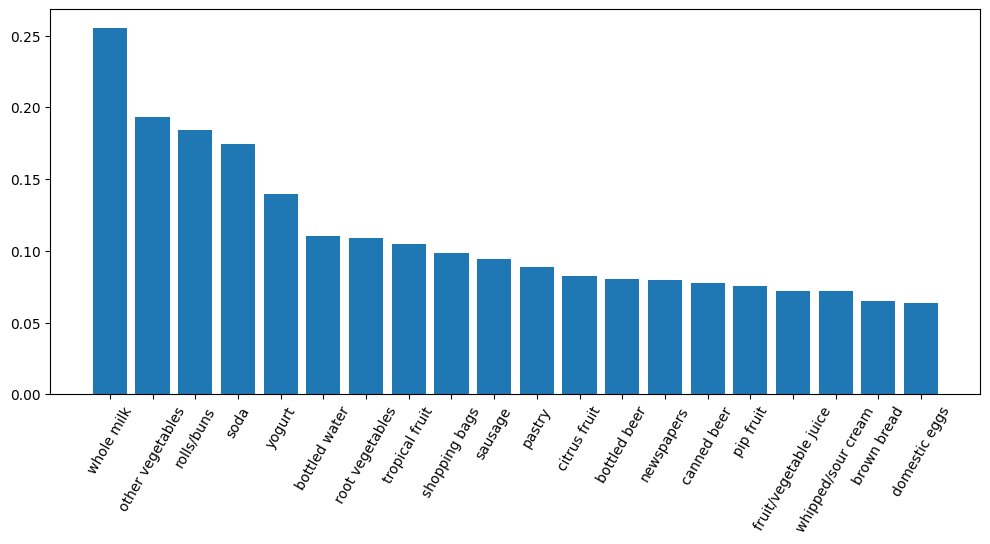

가장 많이 판매된 상품


,item,support,count
0,whole milk,0.255516,2513


가장 적게 판매된 상품


,item,support,count
168,sound storage medium,0.000102,1


In [72]:
top20 = item_freq_df.head(20)
plt.figure(figsize=(12,5))
plt.bar(
    top20["item"],
    top20["support"]
)
plt.xticks(rotation=60)
plt.show()

print("가장 많이 판매된 상품")
display(top20.head(1))

print("가장 적게 판매된 상품")
display(item_freq_df.tail(1))